<a href="https://colab.research.google.com/github/click2shivesh/shivesh-uta-aiml-py/blob/main/Shivesh_INN_ReneWind_Neural_Networks_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ReneWind Neural Networks Project - Full Code Solution

## Business Context
Renewable energy is becoming increasingly important as organisations work to reduce the environmental impact of energy production. Wind energy is one of the most mature renewable energy technologies, and predictive maintenance is a key lever for reducing turbine downtime and maintenance cost.

In this project, ReneWind wants to use sensor data from wind turbine generators to predict generator failures before they happen. Early detection allows the business to inspect or repair components before a breakdown occurs.

## Objective
The objective is to build, tune, and compare Neural Network classification models that can identify generator failures.

The business interpretation of model outcomes is:

- **True Positive (TP):** Actual failure correctly detected. This leads to repair cost.
- **False Negative (FN):** Actual failure missed by the model. This leads to replacement cost and is the most expensive error.
- **False Positive (FP):** Failure predicted, but no actual failure occurred. This leads to inspection cost.
- **True Negative (TN):** No failure correctly predicted.

Since replacement cost is higher than repair cost, and repair cost is higher than inspection cost, the model should focus on reducing **False Negatives**. Therefore, **Recall for the failure class (`Target = 1`)** will be treated as the primary evaluation metric, supported by F1-score, Precision, ROC-AUC, PR-AUC, and confusion matrix analysis.

# Installing and Importing the Necessary Libraries

In [49]:
# Installing the libraries with the specified versions
# Run this cell in Google Colab if the required versions are not already available.
# After installation, restart the runtime and run the notebook sequentially from the next cell.

!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib==3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

In [50]:
# Importing libraries for data manipulation and numerical computation
import numpy as np
import pandas as pd

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing preprocessing and model selection utilities
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Importing model evaluation metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Importing TensorFlow/Keras libraries for Neural Network modeling
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppressing unnecessary warnings for a cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# Setting display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

# Setting random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Loading the Data

In [51]:
# Mounting Google Drive to access the project datasets
# Skip this cell if running locally and update the file paths accordingly.
from google.colab import drive
drive.mount('/content/drive')

# Defining file paths for train and test datasets
train_path = "/content/drive/MyDrive/AIML-UTA-PY/Train.csv"
test_path  = "/content/drive/MyDrive/AIML-UTA-PY/Test.csv"

# Loading the datasets
train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# Displaying the dimensions of both datasets
train_df.shape, test_df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


((20000, 41), (5000, 41))

### Observations

- The training dataset contains **20,000 observations and 41 columns**.
- The test dataset contains **5,000 observations and 41 columns**.
- Both datasets have the same structure, which means they contain the same predictor variables and the target variable.
- As per the problem statement, there are **40 anonymized sensor predictors** and **1 binary target variable**.
- The target variable is `Target`, where `1` represents generator failure and `0` represents no failure.

# Data Overview

In [52]:
# Displaying the first five observations from the training data
train_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.4646,-4.6791,3.1015,0.5061,-0.2211,-2.0325,-2.9109,0.0507,-1.5224,3.7619,-5.7147,0.7359,0.9813,1.4179,-3.3758,-3.0473,0.3062,2.9141,2.2700,4.3949,-2.3883,0.6464,-1.1905,3.1330,0.6653,-2.5108,-0.0367,0.7262,-3.9822,-1.0726,1.6671,3.0597,-1.6904,2.8463,2.2352,6.6675,0.4438,-2.3692,2.9506,-3.4803,0
1,3.3659,3.6534,0.9097,-1.3675,0.3320,2.3589,0.7326,-4.3321,0.5657,-0.1011,1.9145,-0.9515,-1.2553,-2.7065,0.1932,-4.7694,-2.2053,0.9077,0.7569,-5.8337,-3.0651,1.5966,-1.7573,1.7664,-0.2671,3.6250,1.5003,-0.5857,0.7830,-0.2012,0.0249,-1.7955,3.0328,-2.4675,1.8946,-2.2978,-1.7310,5.9088,-0.3863,0.6162,0
2,-3.8318,-5.8244,0.6340,-2.4188,-1.7738,1.0168,-2.0989,-3.1732,-2.0819,5.3926,-0.7707,1.1067,1.1443,0.9433,-3.1638,-4.2478,-4.0389,3.6885,3.3112,1.0590,-2.1430,1.6501,-1.6606,1.6799,-0.4508,-4.5507,3.7388,1.1344,-2.0335,0.8408,-1.6004,-0.2571,0.8035,4.0862,2.2921,5.3608,0.3520,2.9400,3.8392,-4.3094,0
3,1.6181,1.8883,7.0461,-1.1473,0.0831,-1.5298,0.2073,-2.4936,0.3449,2.1186,-3.0530,0.4597,2.7045,-0.6361,-0.4537,-3.1740,-3.4043,-1.2815,1.5821,-1.9518,-3.5166,-1.2060,-5.6279,-1.8177,2.1241,5.2946,4.7481,-2.3085,-3.9630,-6.0287,4.9488,-3.5844,-2.5775,1.3638,0.6227,5.5501,-1.5268,0.1389,3.1014,-1.2774,0
4,-0.1114,3.8725,-3.7584,-2.9829,3.7927,0.5450,0.2054,4.8490,-1.8549,-6.2200,1.9983,4.7238,0.7091,-1.9894,-2.6327,4.1844,2.2454,3.7345,-6.3128,-5.3799,-0.8867,2.0617,9.4456,4.4900,-3.9451,4.5821,-8.7804,-3.3830,5.1065,6.7875,2.0442,8.2659,6.6292,-10.0687,1.2230,-3.2298,1.6869,-2.1639,-3.6446,6.5103,0


In [53]:
# Displaying the first five observations from the test data
test_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.6135,-3.8196,2.2023,1.3004,-1.1849,-4.4960,-1.8358,4.7230,1.2061,-0.3419,-5.1229,1.0170,4.8185,3.2690,-2.9843,1.3874,2.0320,-0.5116,-1.0231,7.3387,-2.2422,0.1555,2.0538,-2.7723,1.8514,-1.7887,-0.2773,-1.2551,-3.8329,-1.5045,1.5868,2.2912,-5.4114,0.8701,0.5745,4.1572,1.4281,-10.5113,0.4547,-1.4484,0
1,0.3896,-0.5123,0.5271,-2.5768,-1.0168,2.2351,-0.4413,-4.4057,-0.3329,1.9668,1.7965,0.4105,0.6383,-1.3896,-1.8834,-5.0179,-3.8272,2.4181,1.7623,-3.2423,-3.1930,1.8575,-1.7080,0.6334,-0.5879,0.0837,3.0139,-0.1823,0.2239,0.8652,-1.7822,-2.4749,2.4936,0.3152,2.0593,0.6839,-0.4855,5.1284,1.7207,-1.4882,0
2,-0.8749,-0.6406,4.0842,-1.5905,0.5259,-1.9576,-0.6954,1.3473,-1.7323,0.4665,-4.9282,3.5651,-0.4493,-0.6562,-0.1665,-1.6302,2.2919,2.3965,0.6013,1.7935,-2.1202,0.4820,-0.8407,1.7902,1.8744,0.3639,-0.1691,-0.4838,-2.1190,-2.1566,2.9073,-1.3189,-2.9975,0.4597,0.6198,5.6315,1.3235,-1.7522,1.8083,1.6757,0
3,0.2384,1.4586,4.0145,2.5345,1.1970,-3.1173,-0.9240,0.2695,1.3224,0.7023,-5.5783,-0.8507,2.5905,0.7674,-2.3908,-2.3420,0.5719,-0.9338,0.5087,1.2107,-3.2595,0.1046,-0.6589,1.4981,1.1003,4.1430,-0.2484,-1.1365,-5.3558,-4.5459,3.8087,3.5179,-3.0741,-0.2842,0.9546,3.0293,-1.3672,-3.4121,0.9060,-2.4509,0
4,5.8282,2.7683,-1.2345,2.8093,-1.6416,-1.4067,0.5686,0.9650,1.9184,-2.7749,-0.5300,1.3745,-0.6509,-1.6795,-0.3792,-4.4431,3.8939,-0.6076,2.9449,0.3672,-5.7891,4.5975,4.4503,3.2249,0.3967,0.2478,-2.3620,1.0794,-0.4731,2.2428,-3.5914,1.7738,-1.5016,-2.2267,4.7768,-6.5597,-0.8056,-0.2760,-3.8582,-0.5377,0


### Observations

- The predictor variables are named `V1` to `V40`, indicating that the actual sensor names have been anonymized due to confidentiality.
- All predictors appear to be numerical, which makes the data suitable for Neural Network modeling.
- Since the variables are ciphered, individual feature-level business interpretation is limited.
- The focus of the project will therefore be on model performance, cost-sensitive error reduction, and operational recommendations.

In [54]:
# Checking the structure of the training dataset
# This helps identify data types, number of columns, and non-null values.
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

### Observations

- The dataset contains **40 predictor variables** and **1 target variable**.
- All predictor variables are numerical and stored as `float64`.
- The target variable is stored as `int64`.
- Variables `V1` and `V2` contain a small number of missing values.
- Neural Networks are sensitive to feature scale, so feature standardization will be required before model training.

In [55]:
# Generating summary statistics for numerical variables
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0000,-0.2720,3.4416,-11.8765,-2.7371,-0.7479,1.8401,15.4930
V2,19982.0000,0.4404,3.1508,-12.3200,-1.6407,0.4715,2.5440,13.0893
V3,20000.0000,2.4847,3.3890,-10.7081,0.2069,2.2558,4.5662,17.0909
V4,20000.0000,-0.0832,3.4316,-15.0821,-2.3477,-0.1352,2.1306,13.2364
V5,20000.0000,-0.0538,2.1048,-8.6034,-1.5356,-0.1020,1.3405,8.1338
V6,20000.0000,-0.9954,2.0410,-10.2271,-2.3472,-1.0005,0.3803,6.9758
V7,20000.0000,-0.8793,1.7616,-7.9497,-2.0309,-0.9172,0.2237,8.0061
V8,20000.0000,-0.5482,3.2958,-15.6576,-2.6427,-0.3891,1.7230,11.6795
V9,20000.0000,-0.0168,2.1606,-8.5963,-1.4950,-0.0676,1.4092,8.1376
V10,20000.0000,-0.0130,2.1932,-9.8540,-1.4112,0.1010,1.4770,8.1085


### Observations

- The predictors have different ranges and scales.
- Some variables contain negative values, while others have relatively large positive values.
- The difference in scale confirms that feature standardization is necessary before training Neural Networks.
- Some variables show wide gaps between minimum and maximum values, suggesting possible outliers or transformed sensor extremes.
- Since the variables are anonymized sensor readings, outliers will not be removed directly unless there is strong evidence that they are data errors.

# Exploratory Data Analysis

The EDA focuses on missing values, duplicate records, class distribution, feature distributions, and relationships between predictors and the target variable.

## Missing Value Analysis

In [56]:
# Checking the number and percentage of missing values in the training data
missing_train = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_train[missing_train["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
V1,18,0.0900
V2,18,0.0900


In [57]:
# Checking the number and percentage of missing values in the test data
missing_test = pd.DataFrame({
    "Missing Count": test_df.isnull().sum(),
    "Missing Percentage": (test_df.isnull().sum() / len(test_df)) * 100
})

missing_test[missing_test["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
V2,6,0.1200
V1,5,0.1000


### Observations

- Missing values are present only in `V1` and `V2`.
- The missing value percentage is extremely small in both training and test datasets.
- Since the variables are numerical, median imputation is a suitable approach.
- Median imputation is preferred over mean imputation because it is more robust to extreme values.
- To avoid data leakage, the imputer will be fitted only on the training subset after the train-validation split, and then applied to validation and test data.

## Duplicate Value Analysis

In [58]:
# Checking duplicate observations in train and test datasets
print("Duplicate rows in training data:", train_df.duplicated().sum())
print("Duplicate rows in test data:", test_df.duplicated().sum())

Duplicate rows in training data: 0
Duplicate rows in test data: 0


### Observations

- No duplicate records are present in either the training dataset or the test dataset.
- Therefore, no duplicate treatment is required.

## Univariate Analysis

In [59]:
# Checking the count and percentage distribution of the target variable
target_distribution = pd.DataFrame({
    "Count": train_df["Target"].value_counts(),
    "Percentage": train_df["Target"].value_counts(normalize=True) * 100
})

target_distribution

,Count,Percentage
Target,,
0,18890,94.4500
1,1110,5.5500


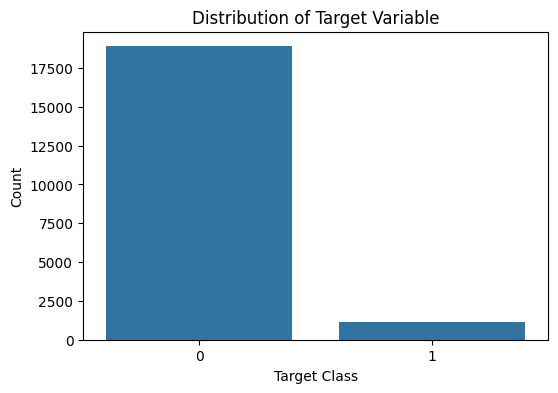

In [60]:
# Visualizing the class distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=train_df)
plt.title("Distribution of Target Variable")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

### Observations

- The target variable is highly imbalanced.
- The majority class is `Target = 0`, representing no generator failure.
- The minority class is `Target = 1`, representing generator failure.
- Failure cases account for only around **5.5%** of the training observations.
- Since failures are rare but expensive to miss, accuracy alone is not a suitable metric.
- The model should prioritise **Recall for class 1**, because a missed failure can lead to expensive generator replacement.

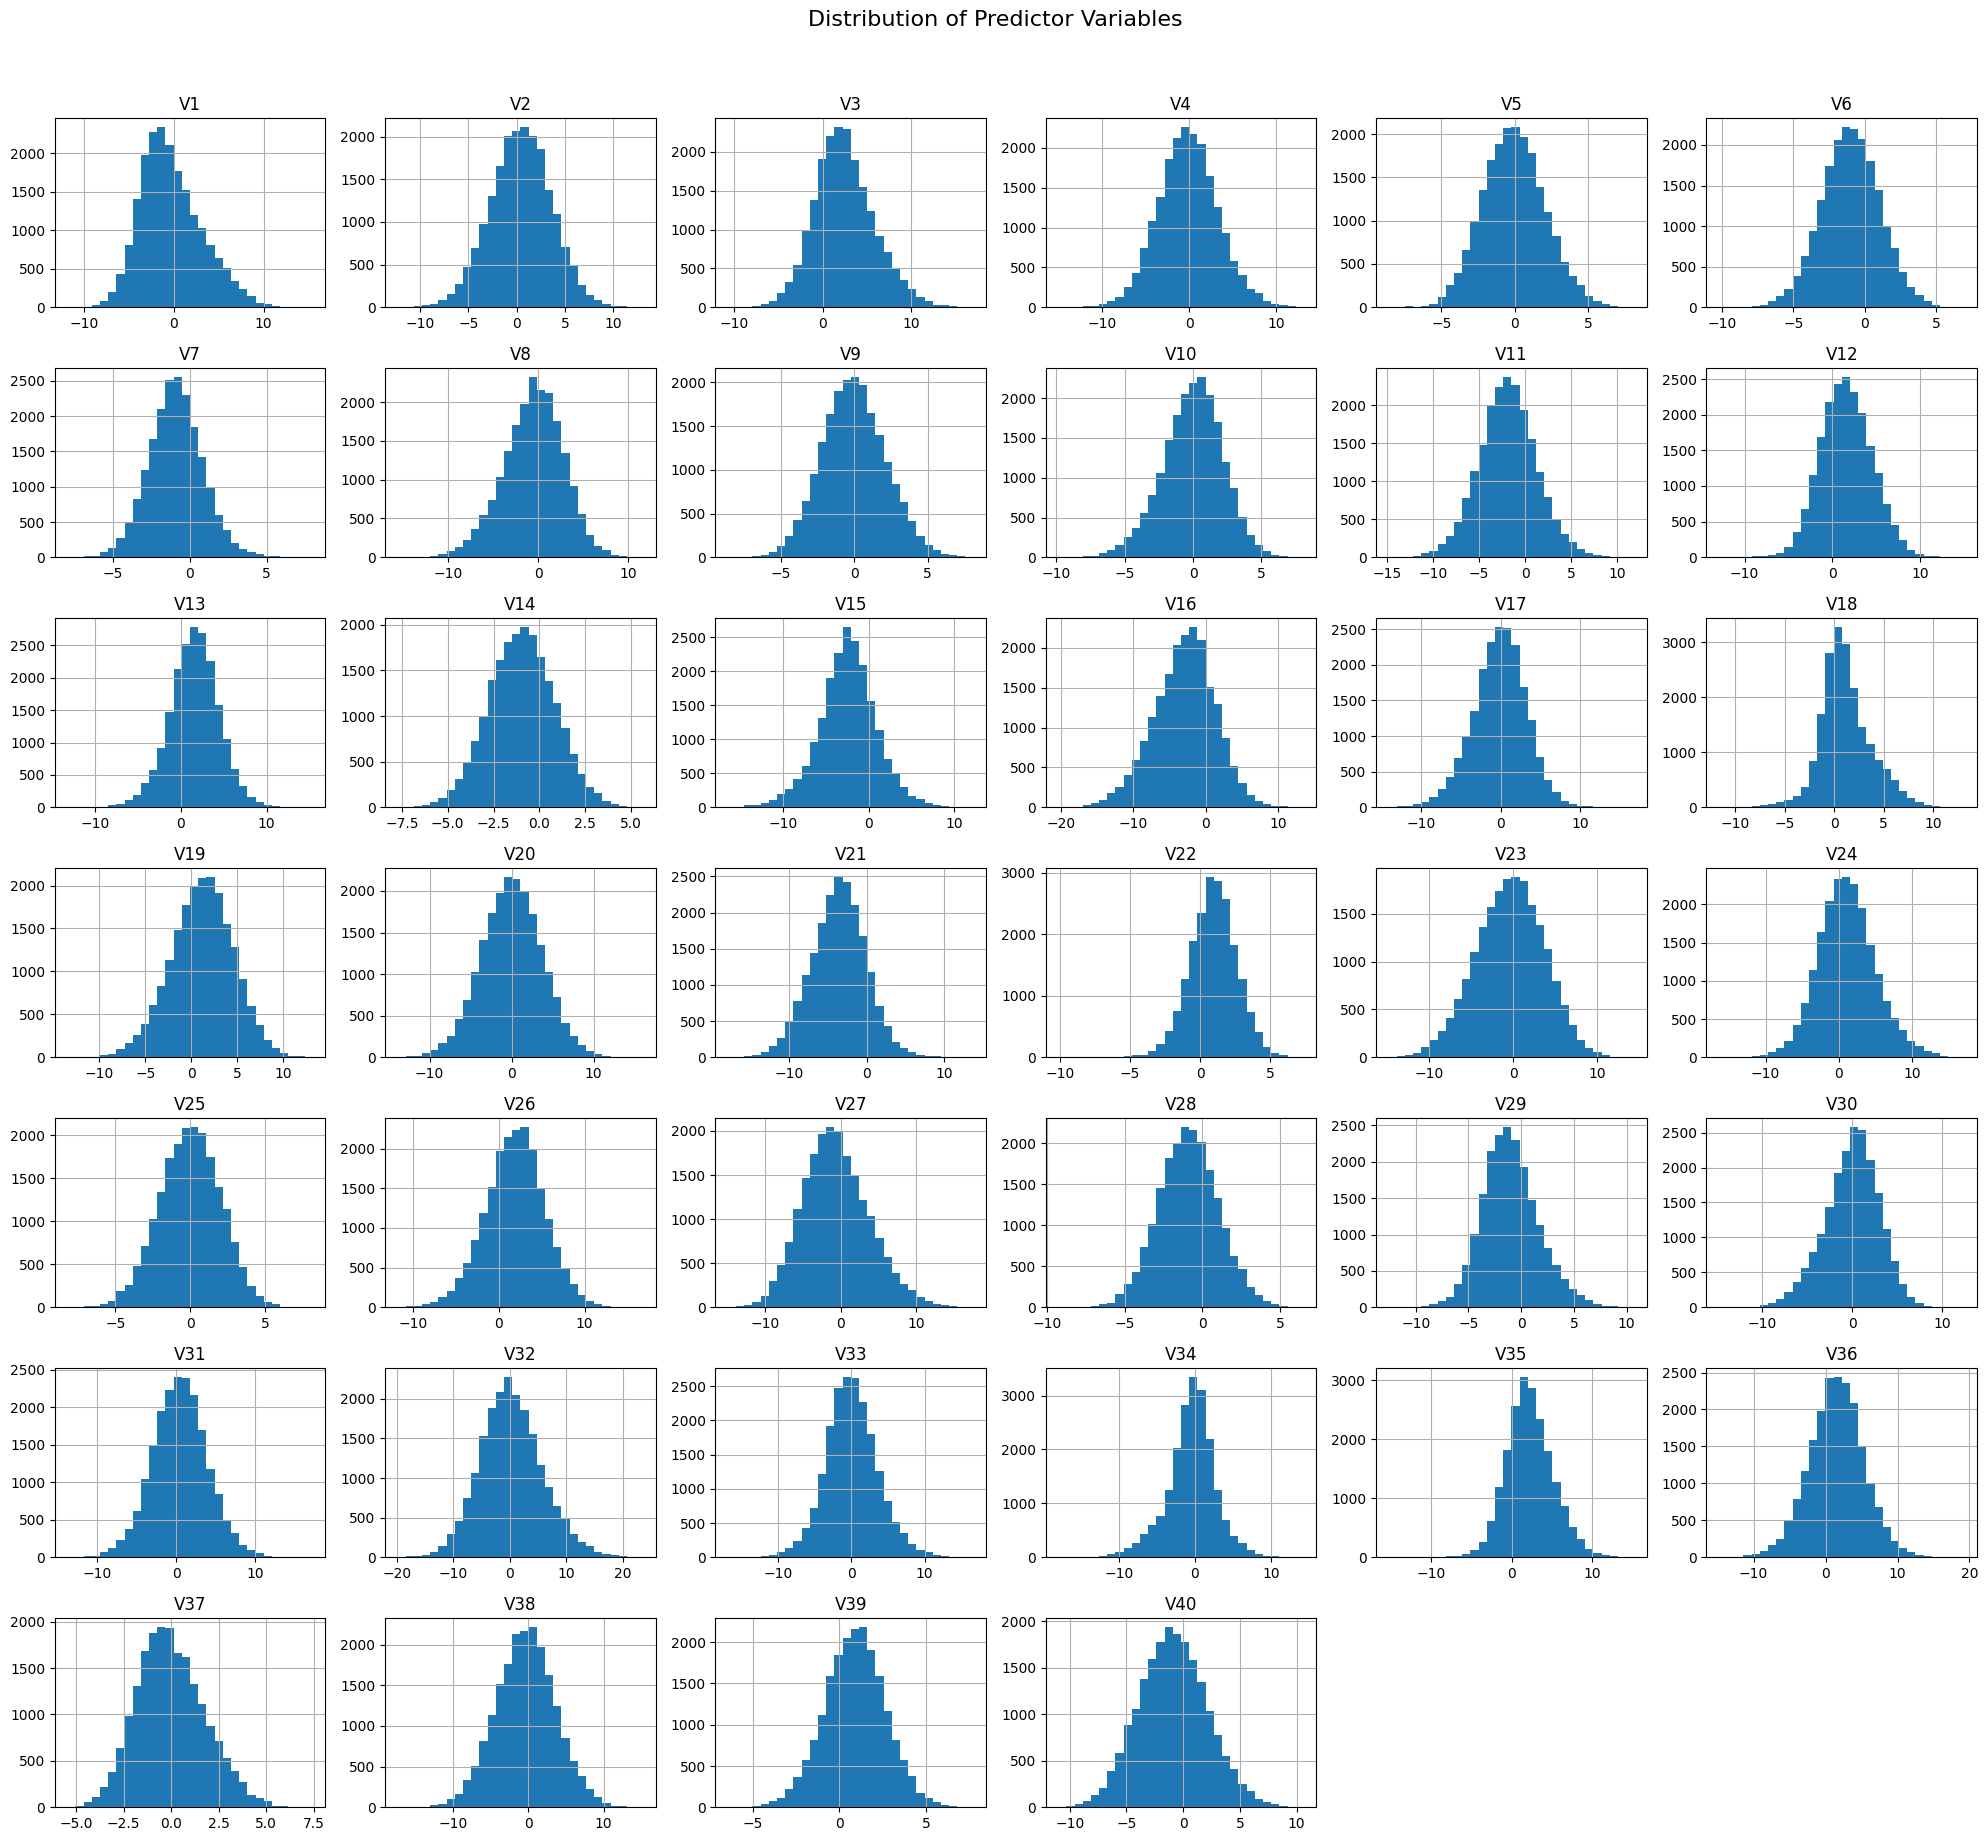

In [61]:
# Separating predictor columns for visualization
predictor_cols = [col for col in train_df.columns if col != "Target"]

# Plotting histograms for all predictor variables to understand their distributions
train_df[predictor_cols].hist(figsize=(20, 18), bins=30)
plt.suptitle("Distribution of Predictor Variables", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Generic Observations for Predictor Distributions

- All predictor variables are numerical and appear to be transformed sensor readings.
- Several predictors are approximately centered around zero, while some variables have wider ranges.
- The feature distributions are not identical, which is expected because they may represent different turbine sensors or transformed measurements.
- Neural Networks benefit from scaled inputs, so standardization will be applied before model building.

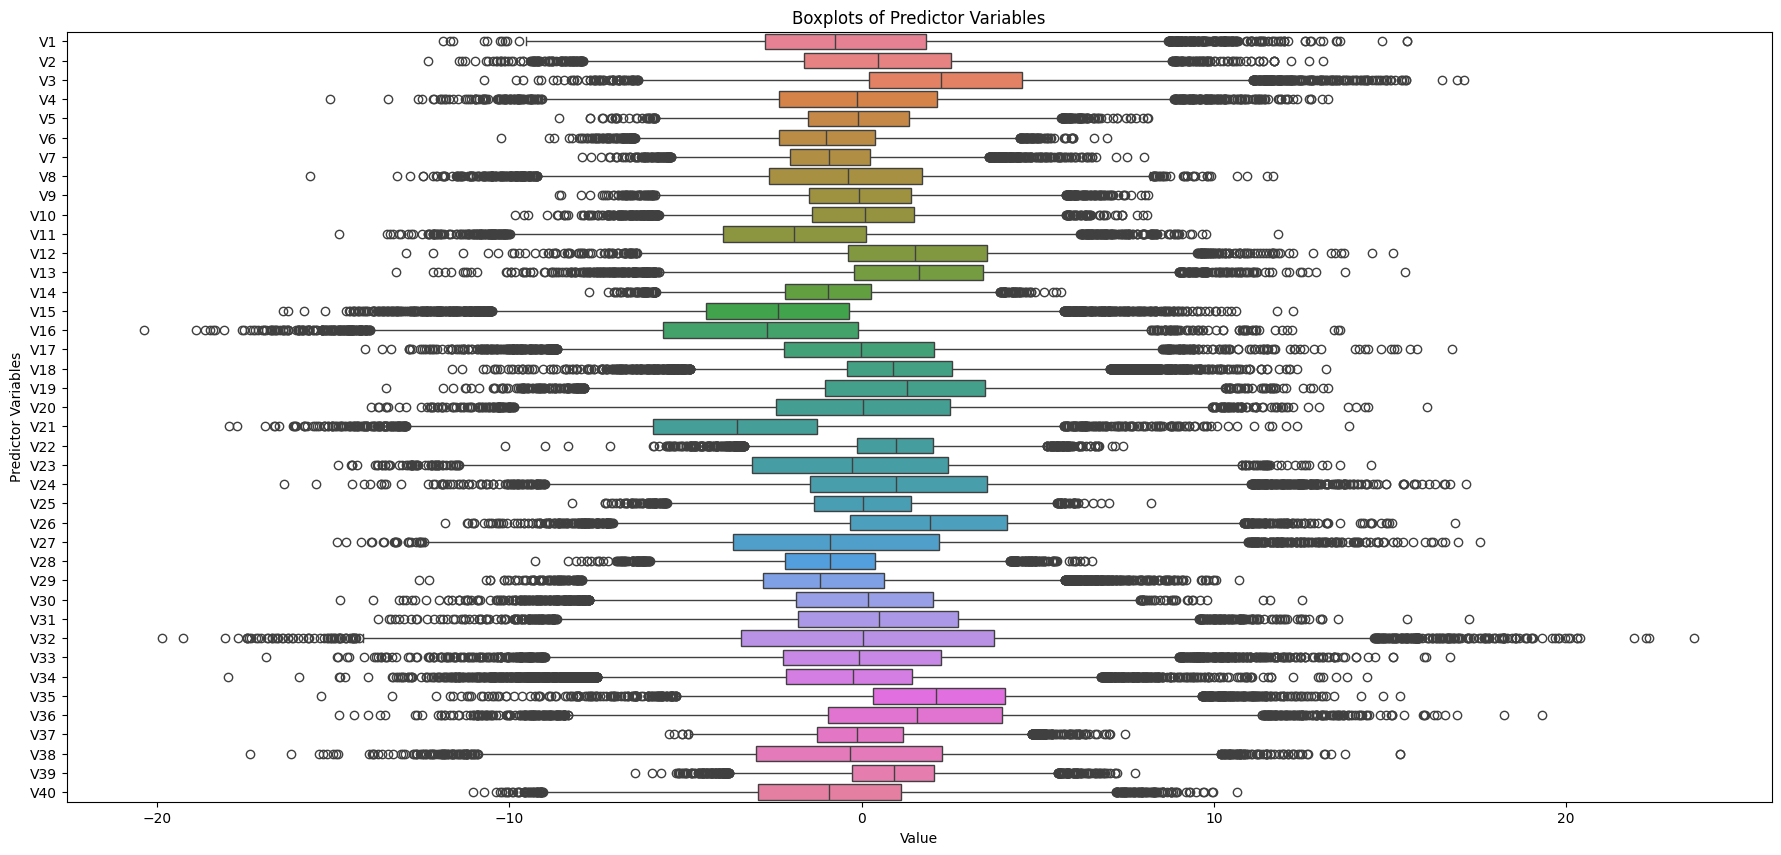

In [62]:
# Visualizing boxplots for all predictor variables to check spread and possible outliers
plt.figure(figsize=(22, 10))
sns.boxplot(data=train_df[predictor_cols], orient="h")
plt.title("Boxplots of Predictor Variables")
plt.xlabel("Value")
plt.ylabel("Predictor Variables")
plt.show()

### Observations

- Some variables show a wide spread and potential outliers.
- Since the predictors are anonymized sensor readings, these extreme values may represent valid operating conditions rather than data errors.
- The outliers will not be removed at this stage to avoid losing potentially important failure signals.
- Scaling will help reduce the effect of different feature magnitudes during Neural Network training.

## Bivariate Analysis

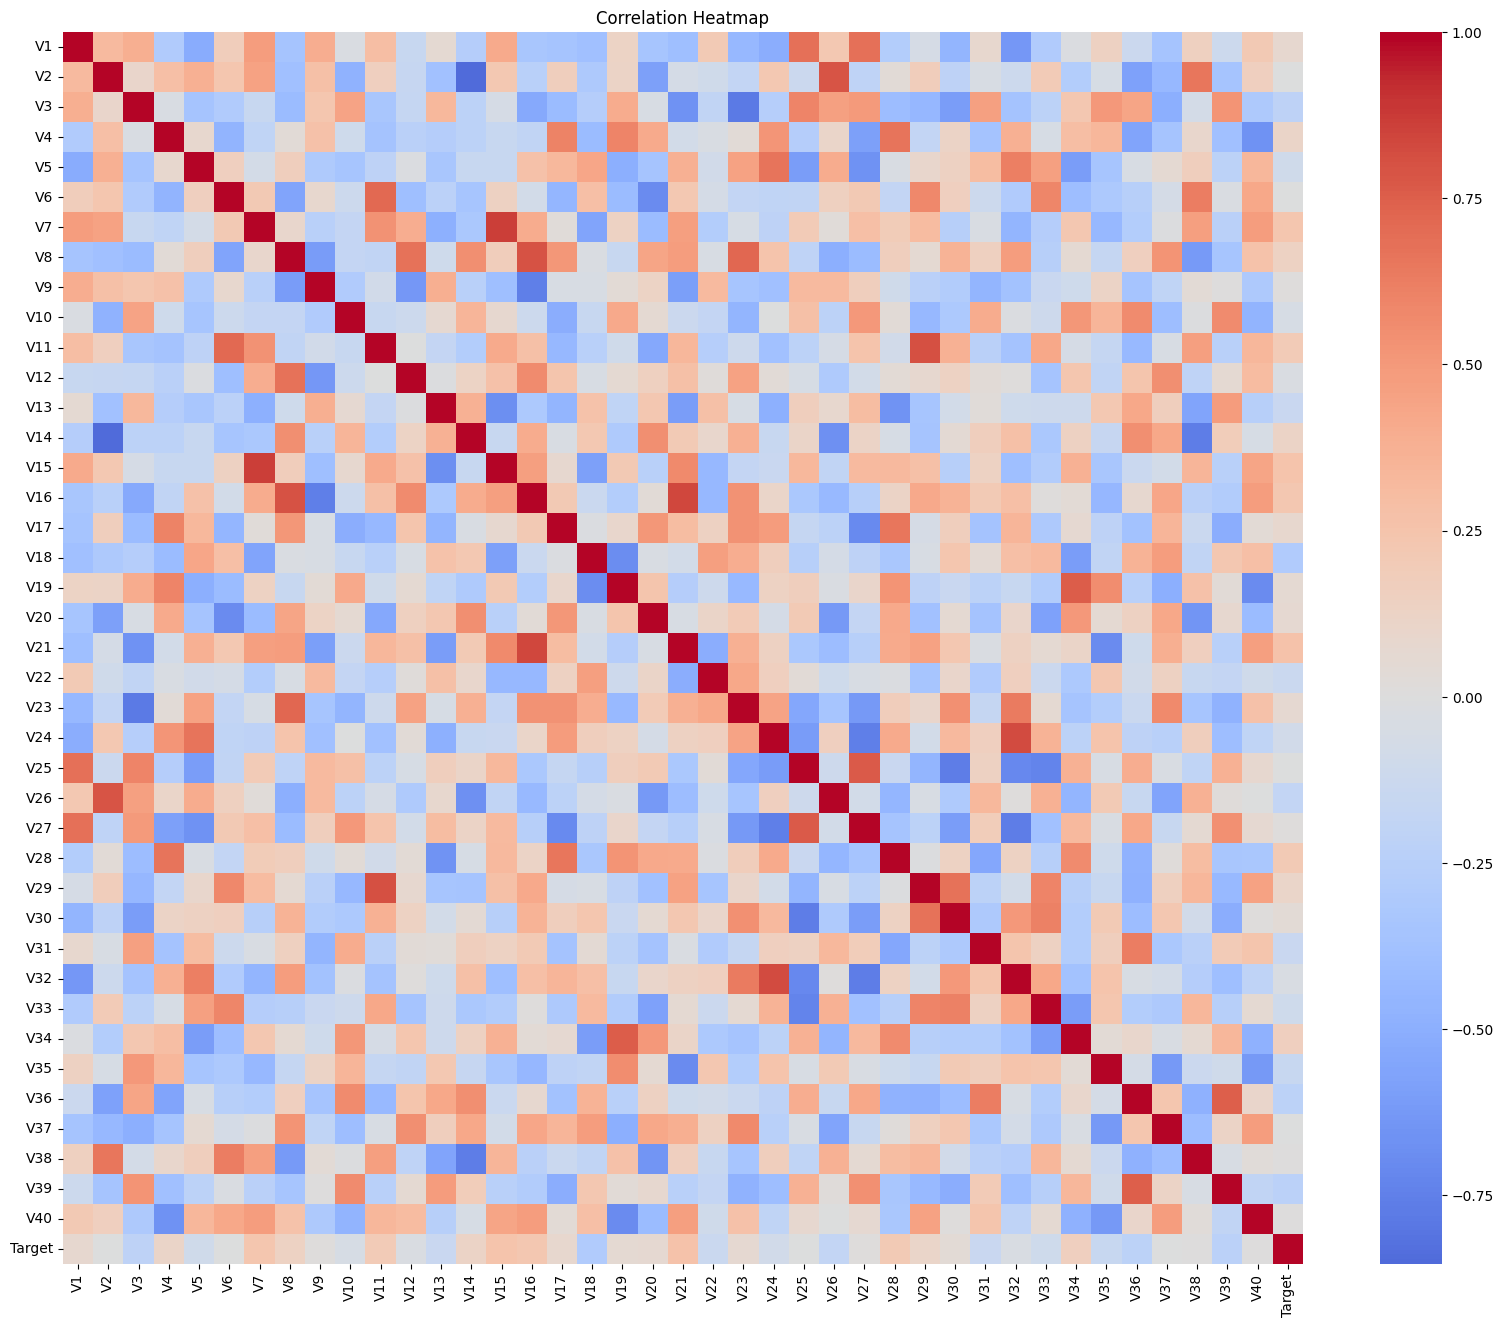

In [63]:
# Computing correlation matrix
corr_matrix = train_df.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Observations

- The heatmap helps identify relationships among predictor variables and between predictors and the target.
- Since the variables are anonymized, correlation analysis is mainly useful for understanding statistical relationships rather than direct business interpretation.
- Strongly correlated predictors may carry overlapping information, but Neural Networks can generally handle correlated inputs.
- No feature will be removed based only on correlation because the dataset has a manageable number of predictors and the model may learn useful nonlinear relationships.

In [64]:
# Checking correlation of predictor variables with the target variable
corr_with_target = corr_matrix["Target"].drop("Target").sort_values(ascending=False)

# Displaying the top positively and negatively correlated features with the target
print("Top 10 positively correlated features with Target:")
display(corr_with_target.head(10))

print("\nTop 10 negatively correlated features with Target:")
display(corr_with_target.tail(10))

Top 10 positively correlated features with Target:


,Target
V21,0.2564
V15,0.2491
V7,0.2369
V16,0.2305
V28,0.2074
V11,0.1967
V34,0.1539
V8,0.1360
V14,0.1176
V4,0.1108



Top 10 negatively correlated features with Target:


,Target
V33,-0.1025
V22,-0.1347
V31,-0.1370
V13,-0.1397
V35,-0.1456
V26,-0.1805
V3,-0.2139
V36,-0.2165
V39,-0.2273
V18,-0.2933


In [65]:
# Selecting top features based on absolute correlation with target
important_features = corr_with_target.abs().sort_values(ascending=False).head(8).index.tolist()
important_features

['V18', 'V21', 'V15', 'V7', 'V16', 'V39', 'V36', 'V3']

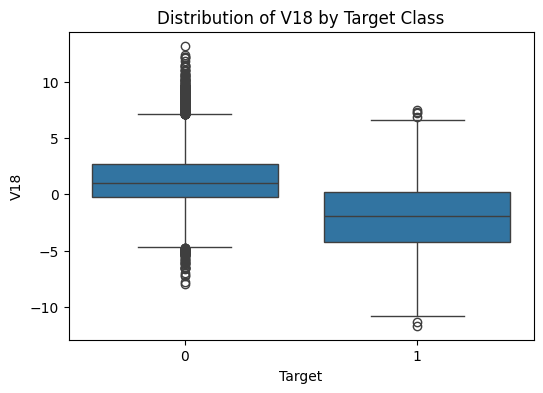

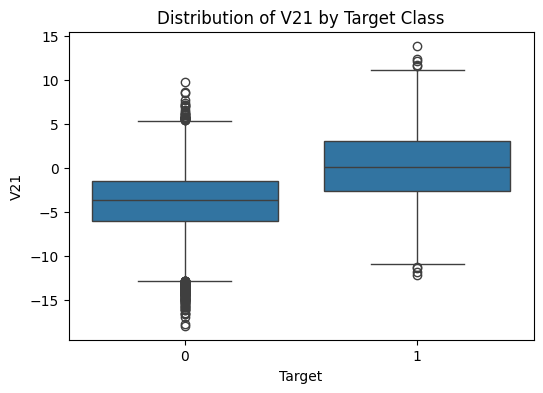

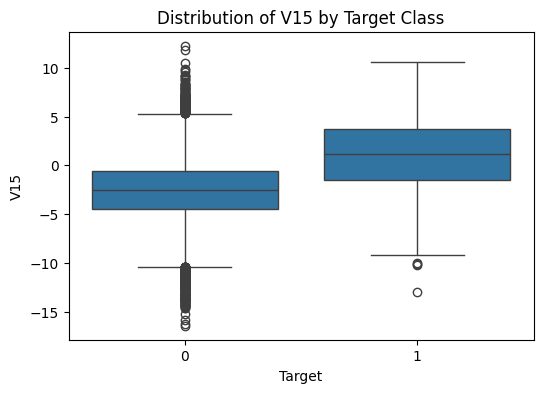

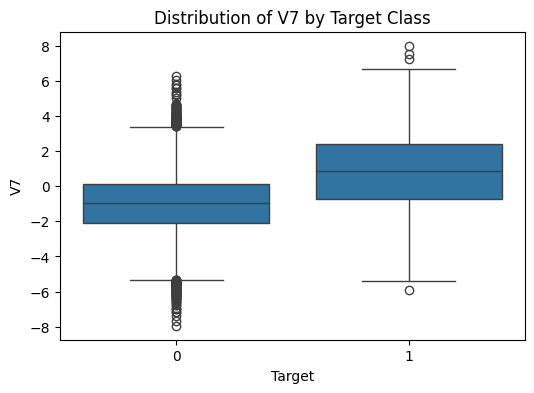

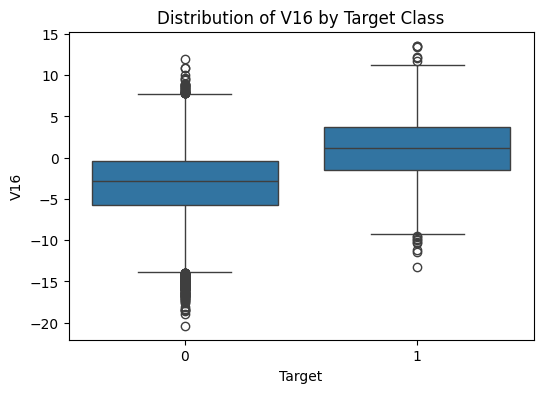

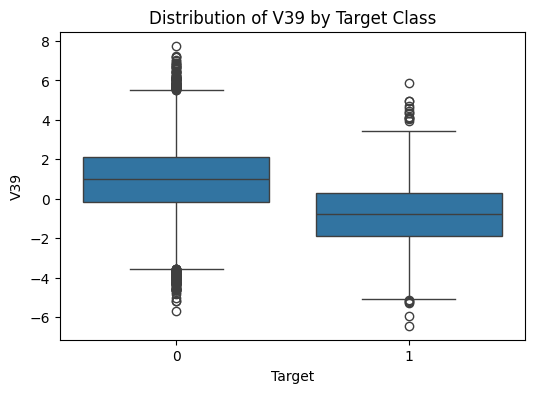

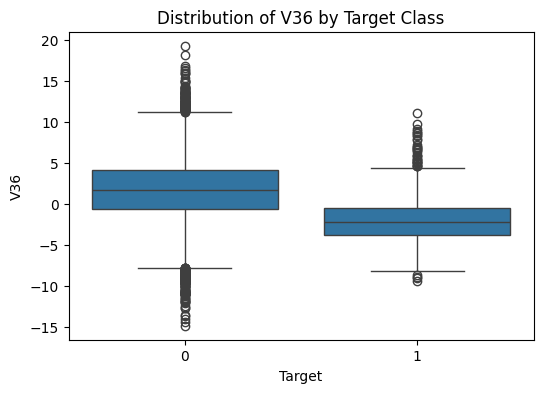

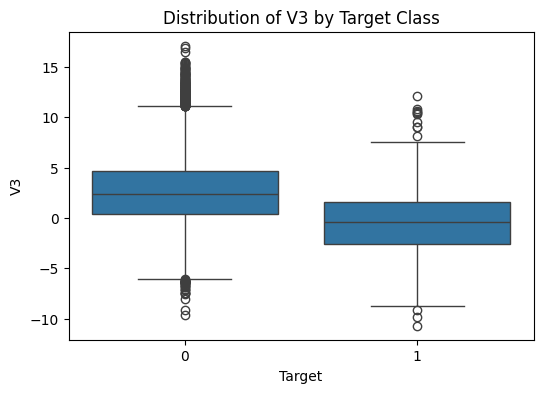

In [66]:
# Comparing the distribution of the most target-correlated features across target classes
for col in important_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Target", y=col, data=train_df)
    plt.title(f"Distribution of {col} by Target Class")
    plt.show()

### Observations

- The selected features show some distributional differences across failure and non-failure classes.
- These differences suggest that the sensor readings contain predictive signals for generator failure.
- However, the separation between the two classes is not expected to be perfectly linear, so Neural Networks are suitable because they can capture nonlinear relationships.

# Data Preprocessing

In [67]:
# Separating predictors and target variable
X = train_df.drop("Target", axis=1)
y = train_df["Target"]

X_test_final = test_df.drop("Target", axis=1)
y_test_final = test_df["Target"]

# Splitting the original training data into training and validation subsets
# Stratification preserves the minority failure class ratio in both subsets.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training subset shape:", X_train.shape)
print("Validation subset shape:", X_val.shape)
print("Final test set shape:", X_test_final.shape)

Training subset shape: (16000, 40)
Validation subset shape: (4000, 40)
Final test set shape: (5000, 40)


In [68]:
# Checking target distribution after stratified split
print("Training target distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation target distribution (%):")
print((y_val.value_counts(normalize=True) * 100).round(2))

Training target distribution (%):
Target
0   94.4500
1    5.5500
Name: proportion, dtype: float64

Validation target distribution (%):
Target
0   94.4500
1    5.5500
Name: proportion, dtype: float64


In [69]:
# Applying median imputation
# The imputer is fitted only on X_train to avoid data leakage.
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test_final)

# Applying feature scaling
# The scaler is also fitted only on X_train to avoid data leakage.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Preprocessing completed successfully.")

Preprocessing completed successfully.


In [70]:
# Computing class weights to handle class imbalance during model training
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

class_weights

{np.int64(0): np.float64(0.5293806246691372),
 np.int64(1): np.float64(9.00900900900901)}

### Observations

- The data was split into training and validation subsets using stratification to preserve the failure class ratio.
- Median imputation was applied to treat missing values in `V1` and `V2`.
- Both imputation and scaling were fitted only on the training subset to avoid data leakage.
- Standardization was applied because Neural Networks are sensitive to feature scale.
- Class weights were calculated to give more importance to the minority failure class during selected model training experiments.

# Model Building

## Model Evaluation Criterion

For this predictive maintenance problem, the most important business risk is missing a real generator failure.

- A **False Negative** means the model failed to detect an actual failure. This may lead to generator breakdown and replacement cost.
- A **False Positive** means the model predicted a failure when there was none. This leads to inspection cost, which is less expensive than replacement.

Therefore, the primary metric is:

### Recall for class 1

Recall measures how many actual failures were correctly identified by the model.

Supporting metrics used for comparison:

- Precision for class 1
- F1-score for class 1
- ROC-AUC
- PR-AUC
- Confusion matrix

The final model should provide high recall while maintaining a reasonable balance with precision, so that the business can detect most failures without creating excessive unnecessary inspections.

In [71]:
# Helper function to build a Neural Network model with flexible architecture

def build_nn_model(
    input_dim,
    hidden_layers=[64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
):
    # Builds and compiles a feed-forward Neural Network for binary classification.
    model = Sequential()

    # Adding the first hidden layer with input dimension
    model.add(Dense(hidden_layers[0], activation="relu", input_shape=(input_dim,)))
    if batch_norm:
        model.add(BatchNormalization())
    if dropout_rate is not None:
        model.add(Dropout(dropout_rate))

    # Adding remaining hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))
        if batch_norm:
            model.add(BatchNormalization())
        if dropout_rate is not None:
            model.add(Dropout(dropout_rate))

    # Output layer for binary classification
    model.add(Dense(1, activation="sigmoid"))

    # Selecting optimizer
    if optimizer.lower() == "sgd":
        opt = SGD(learning_rate=learning_rate)
    elif optimizer.lower() == "adam":
        opt = Adam(learning_rate=learning_rate)
    else:
        raise ValueError("optimizer must be either 'sgd' or 'adam'")

    # Compiling the model
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [72]:
# Helper function to evaluate model performance

def evaluate_model(model, X_data, y_true, model_name, threshold=0.50):
    # Evaluates a trained model and returns key classification metrics.
    y_prob = model.predict(X_data, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_1": precision_score(y_true, y_pred, zero_division=0),
        "Recall_1": recall_score(y_true, y_pred, zero_division=0),
        "F1_1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

    return metrics, y_pred, y_prob


def print_detailed_evaluation(model, X_data, y_true, model_name, threshold=0.50):
    # Prints confusion matrix and classification report for a model.
    metrics, y_pred, y_prob = evaluate_model(model, X_data, y_true, model_name, threshold)

    print(f"Model: {model_name}")
    print(f"Decision Threshold: {threshold}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("\nKey Metrics:")
    for key, value in metrics.items():
        if key not in ["Model"]:
            print(f"{key}: {value:.4f}" if isinstance(value, float) else f"{key}: {value}")

    return metrics


def plot_training_history(history, title):
    # Plots training and validation loss and recall curves.
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "recall" in history_df.columns:
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["recall"], label="Train Recall")
        plt.plot(history_df["val_recall"], label="Validation Recall")
        plt.title(f"{title} - Recall Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Recall")
        plt.legend()
        plt.show()


def model_observation(metrics):
    # Prints automated business-focused observations for a model.
    recall = metrics["Recall_1"]
    precision = metrics["Precision_1"]
    f1 = metrics["F1_1"]
    pr_auc = metrics["PR_AUC"]

    print("Automated Observation:")
    print(f"- The model achieved recall of {recall:.4f} for the failure class.")
    print(f"- Precision for the failure class is {precision:.4f}, indicating the reliability of failure alerts.")
    print(f"- F1-score is {f1:.4f}, showing the balance between recall and precision.")
    print(f"- PR-AUC is {pr_auc:.4f}, which is important for imbalanced classification problems.")

    if recall >= 0.80:
        print("- From a predictive maintenance perspective, this model is strong at identifying actual failures.")
    elif recall >= 0.60:
        print("- The model captures a reasonable proportion of failures, but further improvement is desirable.")
    else:
        print("- The model misses a large proportion of failures and is not ideal for deployment without improvement.")

In [73]:
# Defining callbacks to prevent overfitting and improve convergence
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# Storing validation results for model comparison
validation_results = []
training_results = []

# Initial Model Building and Model Performance Improvement

## Model 0 - Baseline Neural Network with SGD

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9342 - auc: 0.4931 - loss: 0.2920 - pr_auc: 0.0510 - precision: 0.0233 - recall: 0.0045 - val_accuracy: 0.9445 - val_auc: 0.6704 - val_loss: 0.2150 - val_pr_auc: 0.1336 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9445 - auc: 0.7749 - loss: 0.1893 - pr_auc: 0.3006 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9445 - val_auc: 0.8166 - val_loss: 0.1761 - val_pr_auc: 0.4809 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9466 - auc: 0.8609 - loss: 0.1588 - pr_auc: 0.5405 - precision: 1.0000 - recall: 0.0372 - val_accuracy: 0.9505 - val_auc: 0.8673 - val_loss: 0.1517 - val_pr_auc: 0.6203 - val_precision: 1.0000 - val_recall: 0.1081 - learning_rate: 0.0100
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

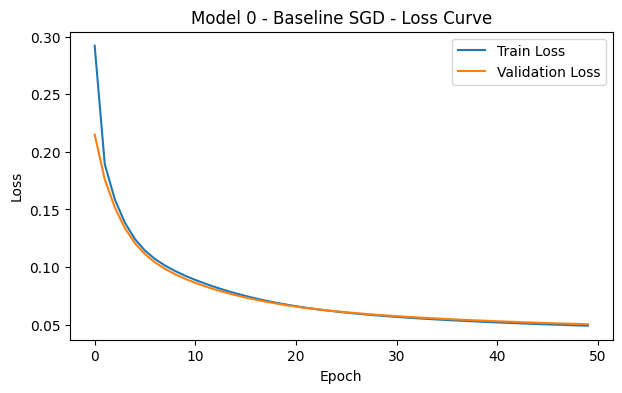

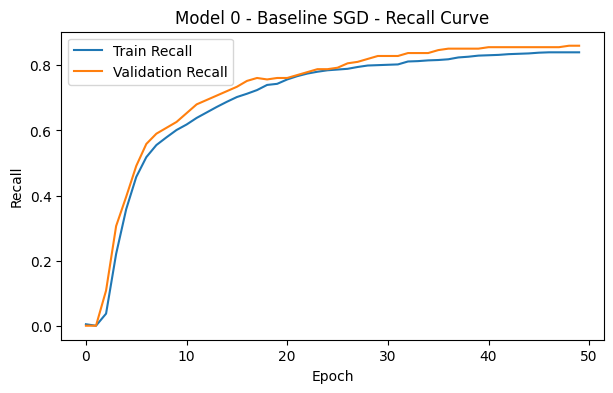

Model: Model 0 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15100    12]
 [  139   749]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9909    0.9992    0.9950     15112
           1     0.9842    0.8435    0.9084       888

    accuracy                         0.9906     16000
   macro avg     0.9876    0.9213    0.9517     16000
weighted avg     0.9905    0.9906    0.9902     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9906
Precision_1: 0.9842
Recall_1: 0.8435
F1_1: 0.9084
ROC_AUC: 0.9595
PR_AUC: 0.9157
Model: Model 0 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3773    5]
 [  31  191]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9919    0.9987    0.9953      3778
           1     0.9745    0.8604    0.9139       222

    accuracy                         0.9910      4000
   macro avg     0.9832    0.9295    0.9546      4000
weighted avg     0.9909    0

In [74]:
model_0 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
)

model_0.summary()

history_0 = model_0.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_0, "Model 0 - Baseline SGD")

train_metrics_0 = print_detailed_evaluation(model_0, X_train_scaled, y_train, "Model 0 - Train")
val_metrics_0 = print_detailed_evaluation(model_0, X_val_scaled, y_val, "Model 0 - Validation")

training_results.append(train_metrics_0)
validation_results.append(val_metrics_0)
model_observation(val_metrics_0)

### Observations for Model 0

- This model is the baseline Neural Network using SGD optimizer, as required by the rubric.
- The baseline model provides the first benchmark for validation recall, precision, F1-score, ROC-AUC, and PR-AUC.
- Because the target class is highly imbalanced, the baseline model may show good accuracy while still missing many failure cases.
- The main purpose of this model is to establish the starting point before applying improvement techniques such as deeper layers, Adam optimizer, dropout, and class weights.

## Model 1 - Deeper Neural Network with SGD

Epoch 1/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9239 - auc: 0.5791 - loss: 0.2644 - pr_auc: 0.0620 - precision: 0.0259 - recall: 0.0101 - val_accuracy: 0.9445 - val_auc: 0.7689 - val_loss: 0.1929 - val_pr_auc: 0.2638 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9473 - auc: 0.8410 - loss: 0.1671 - pr_auc: 0.4699 - precision: 1.0000 - recall: 0.0495 - val_accuracy: 0.9528 - val_auc: 0.8597 - val_loss: 0.1559 - val_pr_auc: 0.5938 - val_precision: 1.0000 - val_recall: 0.1486 - learning_rate: 0.0100
Epoch 3/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9584 - auc: 0.8905 - loss: 0.1391 - pr_auc: 0.6373 - precision: 0.9784 - recall: 0.2556 - val_accuracy: 0.9613 - val_auc: 0.8940 - val_loss: 0.1342 - val_pr_auc: 0.6912 - val_precision: 1.0000 - val_recall: 0.3018 - learning_rate: 0.0100
Epoch 4/60
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9672 - auc: 0.

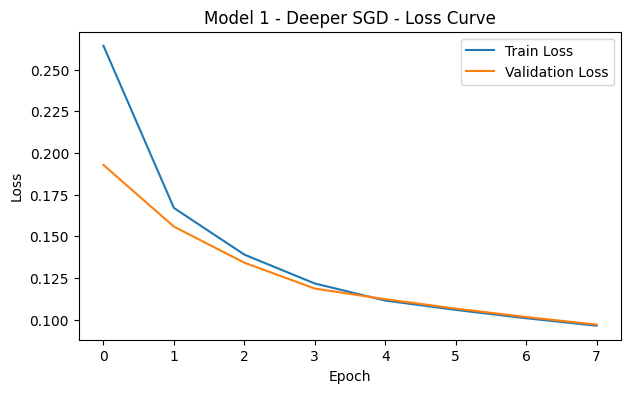

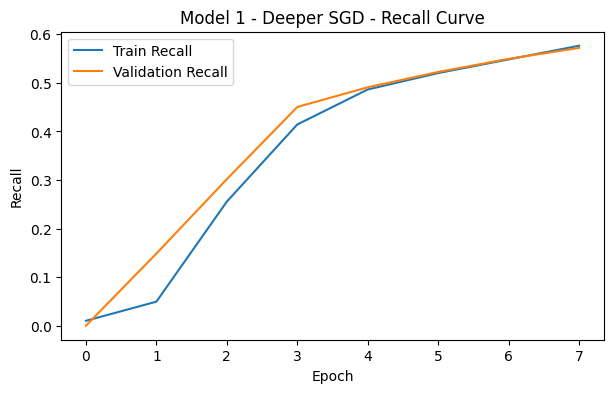

Model: Model 1 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15112     0]
 [  888     0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715     15112
           1     0.0000    0.0000    0.0000       888

    accuracy                         0.9445     16000
   macro avg     0.4723    0.5000    0.4857     16000
weighted avg     0.8921    0.9445    0.9175     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9445
Precision_1: 0.0000
Recall_1: 0.0000
F1_1: 0.0000
ROC_AUC: 0.7874
PR_AUC: 0.2722
Model: Model 1 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3778    0]
 [ 222    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715      3778
           1     0.0000    0.0000    0.0000       222

    accuracy                         0.9445      4000
   macro avg     0.4723    0.5000    0.4857      4000
weighted avg     0.8921    0

In [75]:
model_1 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=None,
    batch_norm=False
)

history_1 = model_1.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=60,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_1, "Model 1 - Deeper SGD")

train_metrics_1 = print_detailed_evaluation(model_1, X_train_scaled, y_train, "Model 1 - Train")
val_metrics_1 = print_detailed_evaluation(model_1, X_val_scaled, y_val, "Model 1 - Validation")

training_results.append(train_metrics_1)
validation_results.append(val_metrics_1)
model_observation(val_metrics_1)

### Observations for Model 1

- This model increases the number of hidden layers and neurons while keeping SGD as the optimizer.
- The objective is to check whether additional model capacity improves the ability to detect nonlinear failure patterns.
- If validation recall improves compared to the baseline, the deeper architecture is helping the model capture more failure-related patterns.
- If training performance improves but validation performance does not, it may indicate overfitting.

## Model 2 - SGD with Dropout Regularization

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9061 - auc: 0.4950 - loss: 0.3328 - pr_auc: 0.0525 - precision: 0.0404 - recall: 0.0304 - val_accuracy: 0.9445 - val_auc: 0.6350 - val_loss: 0.2180 - val_pr_auc: 0.0809 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9444 - auc: 0.6672 - loss: 0.2182 - pr_auc: 0.1039 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9445 - val_auc: 0.7882 - val_loss: 0.1861 - val_pr_auc: 0.3258 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9447 - auc: 0.7693 - loss: 0.1925 - pr_auc: 0.2041 - precision: 1.0000 - recall: 0.0034 - val_accuracy: 0.9445 - val_auc: 0.8445 - val_loss: 0.1671 - val_pr_auc: 0.5422 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0100
Epoch 4/70
244/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

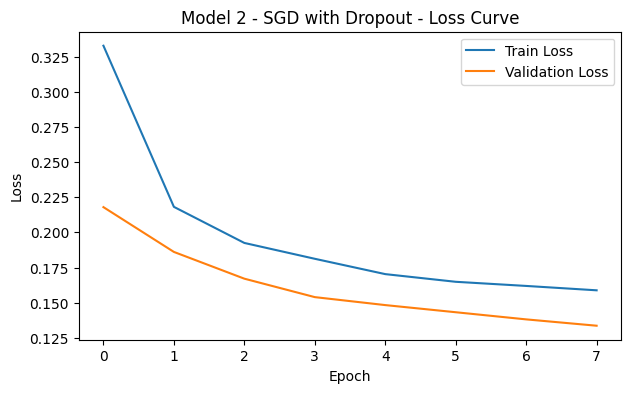

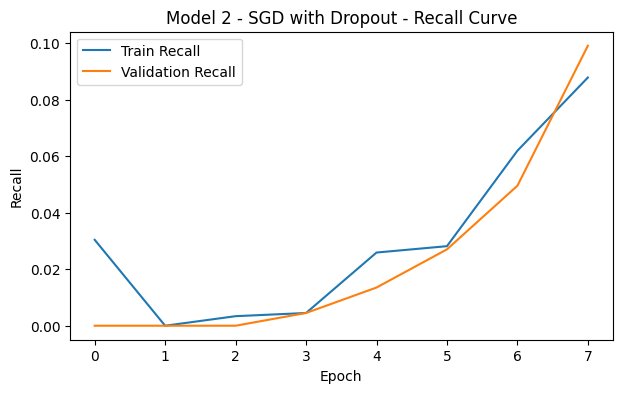

Model: Model 2 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15112     0]
 [  888     0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715     15112
           1     0.0000    0.0000    0.0000       888

    accuracy                         0.9445     16000
   macro avg     0.4723    0.5000    0.4857     16000
weighted avg     0.8921    0.9445    0.9175     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9445
Precision_1: 0.0000
Recall_1: 0.0000
F1_1: 0.0000
ROC_AUC: 0.6843
PR_AUC: 0.0946
Model: Model 2 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3778    0]
 [ 222    0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9445    1.0000    0.9715      3778
           1     0.0000    0.0000    0.0000       222

    accuracy                         0.9445      4000
   macro avg     0.4723    0.5000    0.4857      4000
weighted avg     0.8921    0

In [76]:
model_2 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="sgd",
    learning_rate=0.01,
    dropout_rate=0.30,
    batch_norm=False
)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=70,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_2, "Model 2 - SGD with Dropout")

train_metrics_2 = print_detailed_evaluation(model_2, X_train_scaled, y_train, "Model 2 - Train")
val_metrics_2 = print_detailed_evaluation(model_2, X_val_scaled, y_val, "Model 2 - Validation")

training_results.append(train_metrics_2)
validation_results.append(val_metrics_2)
model_observation(val_metrics_2)

### Observations for Model 2

- Dropout regularization is added to reduce overfitting.
- Dropout randomly switches off a portion of neurons during training, which encourages the model to learn more robust patterns.
- If validation metrics improve while training metrics are slightly lower, dropout is helping generalization.
- The main metric to monitor remains recall for the failure class.

## Model 3 - Neural Network with Adam Optimizer

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9397 - auc: 0.8423 - loss: 0.1819 - pr_auc: 0.3742 - precision: 0.4346 - recall: 0.2883 - val_accuracy: 0.9790 - val_auc: 0.9281 - val_loss: 0.0998 - val_pr_auc: 0.8320 - val_precision: 0.9600 - val_recall: 0.6486 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9795 - auc: 0.9441 - loss: 0.0845 - pr_auc: 0.8405 - precision: 0.9459 - recall: 0.6689 - val_accuracy: 0.9855 - val_auc: 0.9449 - val_loss: 0.0729 - val_pr_auc: 0.8976 - val_precision: 0.9505 - val_recall: 0.7793 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9864 - auc: 0.9511 - loss: 0.0652 - pr_auc: 0.8890 - precision: 0.9679 - recall: 0.7815 - val_accuracy: 0.9898 - val_auc: 0.9475 - val_loss: 0.0598 - val_pr_auc: 0.9155 - val_precision: 0.9594 - val_recall: 0.8514 - learning_rate: 0.0010
Epoch 4/50
232/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9889 - auc: 0.9569 - l

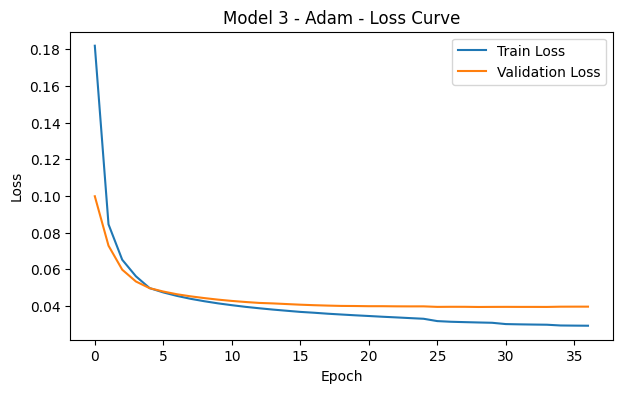

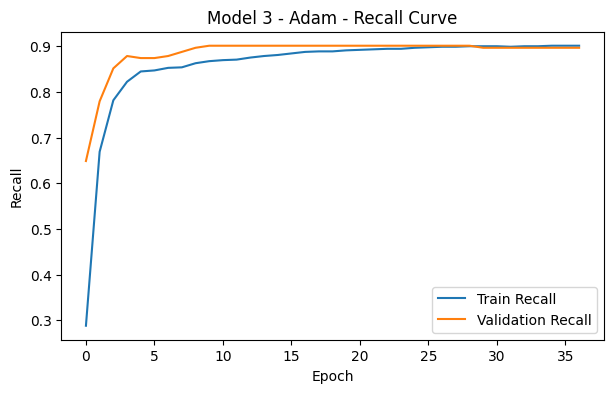

Model: Model 3 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15107     5]
 [   89   799]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9941    0.9997    0.9969     15112
           1     0.9938    0.8998    0.9444       888

    accuracy                         0.9941     16000
   macro avg     0.9940    0.9497    0.9707     16000
weighted avg     0.9941    0.9941    0.9940     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9941
Precision_1: 0.9938
Recall_1: 0.8998
F1_1: 0.9444
ROC_AUC: 0.9867
PR_AUC: 0.9523
Model: Model 3 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3775    3]
 [  22  200]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9942    0.9992    0.9967      3778
           1     0.9852    0.9009    0.9412       222

    accuracy                         0.9938      4000
   macro avg     0.9897    0.9501    0.9689      4000
weighted avg     0.9937    0

In [77]:
model_3 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=None,
    batch_norm=False
)

history_3 = model_3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_3, "Model 3 - Adam")

train_metrics_3 = print_detailed_evaluation(model_3, X_train_scaled, y_train, "Model 3 - Train")
val_metrics_3 = print_detailed_evaluation(model_3, X_val_scaled, y_val, "Model 3 - Validation")

training_results.append(train_metrics_3)
validation_results.append(val_metrics_3)
model_observation(val_metrics_3)

### Observations for Model 3

- This model uses Adam optimizer instead of SGD.
- Adam usually converges faster and adapts the learning rate during training.
- This experiment checks whether optimizer change improves failure detection without adding class weights or dropout.
- Validation recall and PR-AUC should be compared against SGD-based models.

## Model 4 - Adam Optimizer with Dropout

Epoch 1/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9509 - auc: 0.8421 - loss: 0.1745 - pr_auc: 0.4094 - precision: 0.6914 - recall: 0.2095 - val_accuracy: 0.9805 - val_auc: 0.9394 - val_loss: 0.0938 - val_pr_auc: 0.8492 - val_precision: 0.9186 - val_recall: 0.7117 - learning_rate: 0.0010
Epoch 2/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9761 - auc: 0.9329 - loss: 0.0992 - pr_auc: 0.7926 - precision: 0.8953 - recall: 0.6453 - val_accuracy: 0.9875 - val_auc: 0.9477 - val_loss: 0.0661 - val_pr_auc: 0.9067 - val_precision: 0.9574 - val_recall: 0.8108 - learning_rate: 0.0010
Epoch 3/70
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9833 - auc: 0.9439 - loss: 0.0777 - pr_auc: 0.8587 - precision: 0.9258 - recall: 0.7590 - val_accuracy: 0.9900 - val_auc: 0.9505 - val_loss: 0.0561 - val_pr_auc: 0.9147 - val_precision: 0.9643 - val_recall: 0.8514 - learning_rate: 0.0010
Epoch 4/70
245/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9853 - auc: 0.9486 - l

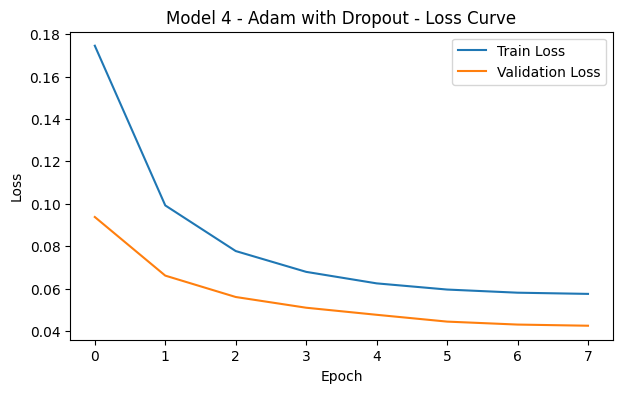

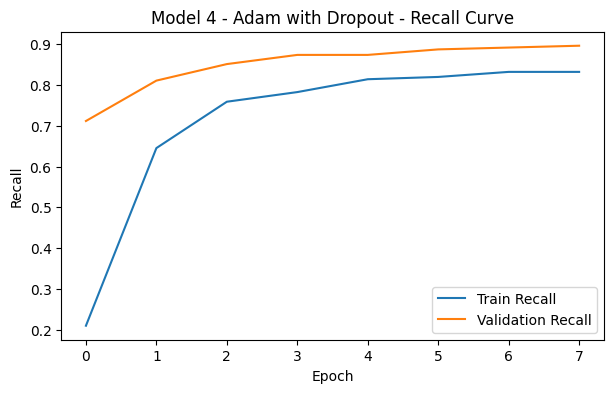

Model: Model 4 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[15053    59]
 [  268   620]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9825    0.9961    0.9893     15112
           1     0.9131    0.6982    0.7913       888

    accuracy                         0.9796     16000
   macro avg     0.9478    0.8471    0.8903     16000
weighted avg     0.9787    0.9796    0.9783     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9796
Precision_1: 0.9131
Recall_1: 0.6982
F1_1: 0.7913
ROC_AUC: 0.9416
PR_AUC: 0.8333
Model: Model 4 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3764   14]
 [  64  158]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9833    0.9963    0.9897      3778
           1     0.9186    0.7117    0.8020       222

    accuracy                         0.9805      4000
   macro avg     0.9509    0.8540    0.8959      4000
weighted avg     0.9797    0

In [78]:
model_4 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.30,
    batch_norm=False
)

history_4 = model_4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=70,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plot_training_history(history_4, "Model 4 - Adam with Dropout")

train_metrics_4 = print_detailed_evaluation(model_4, X_train_scaled, y_train, "Model 4 - Train")
val_metrics_4 = print_detailed_evaluation(model_4, X_val_scaled, y_val, "Model 4 - Validation")

training_results.append(train_metrics_4)
validation_results.append(val_metrics_4)
model_observation(val_metrics_4)

### Observations for Model 4

- This model combines Adam optimizer with dropout regularization.
- Adam helps with faster optimization, while dropout helps reduce overfitting.
- This combination is expected to improve generalization compared to a deeper network without regularization.
- The validation recall and F1-score should be checked to ensure the model is not only learning the majority class.

## Model 5 - Adam with Dropout and Class Weights

Epoch 1/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8045 - auc: 0.8803 - loss: 0.4416 - pr_auc: 0.5643 - precision: 0.1933 - recall: 0.7950 - val_accuracy: 0.9197 - val_auc: 0.9393 - val_loss: 0.2578 - val_pr_auc: 0.8783 - val_precision: 0.4016 - val_recall: 0.9099 - learning_rate: 0.0010
Epoch 2/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9189 - auc: 0.9368 - loss: 0.2983 - pr_auc: 0.8059 - precision: 0.3960 - recall: 0.8795 - val_accuracy: 0.9730 - val_auc: 0.9428 - val_loss: 0.1759 - val_pr_auc: 0.9073 - val_precision: 0.6952 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 3/80
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9452 - auc: 0.9441 - loss: 0.2644 - pr_auc: 0.8525 - precision: 0.5039 - recall: 0.8750 - val_accuracy: 0.9747 - val_auc: 0.9413 - val_loss: 0.1770 - val_pr_auc: 0.9106 - val_precision: 0.7123 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 4/80
235/250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9553 - auc: 0.9496 - 

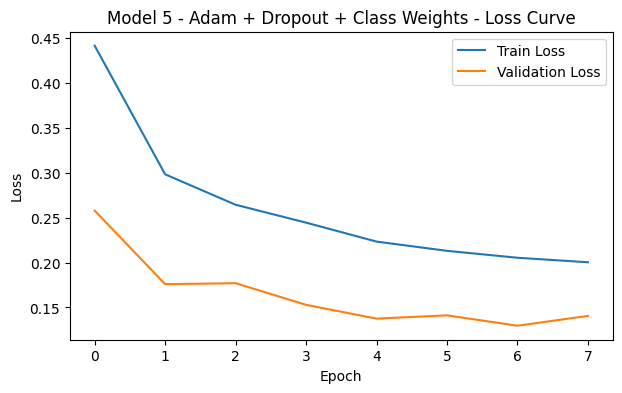

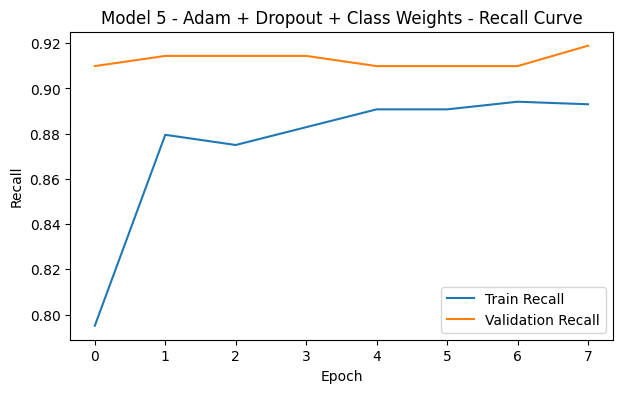

Model: Model 5 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[13889  1223]
 [   93   795]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9933    0.9191    0.9548     15112
           1     0.3940    0.8953    0.5471       888

    accuracy                         0.9177     16000
   macro avg     0.6937    0.9072    0.7510     16000
weighted avg     0.9601    0.9177    0.9321     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9177
Precision_1: 0.3940
Recall_1: 0.8953
F1_1: 0.5471
ROC_AUC: 0.9457
PR_AUC: 0.8583
Model: Model 5 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3477  301]
 [  20  202]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9943    0.9203    0.9559      3778
           1     0.4016    0.9099    0.5572       222

    accuracy                         0.9197      4000
   macro avg     0.6979    0.9151    0.7566      4000
weighted avg     0.9614    0

In [79]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

model_5 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.30,
    batch_norm=False
)

history_5 = model_5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

plot_training_history(history_5, "Model 5 - Adam + Dropout + Class Weights")

train_metrics_5 = print_detailed_evaluation(model_5, X_train_scaled, y_train, "Model 5 - Train")
val_metrics_5 = print_detailed_evaluation(model_5, X_val_scaled, y_val, "Model 5 - Validation")

training_results.append(train_metrics_5)
validation_results.append(val_metrics_5)
model_observation(val_metrics_5)

### Observations for Model 5

- This model combines Adam optimizer, dropout, and class weights.
- Class weights increase the penalty for misclassifying the minority failure class.
- This approach is strongly aligned with the business problem because missing failures is costly.
- Recall is expected to improve, though precision may reduce because the model may flag more turbines for inspection.
- This trade-off can be acceptable because inspection cost is lower than replacement cost.

## Model 6 - Deeper Adam Network with Batch Normalization, Dropout, and Class Weights

Epoch 1/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7593 - auc: 0.8964 - loss: 0.4344 - pr_auc: 0.5766 - precision: 0.1719 - recall: 0.8739 - val_accuracy: 0.9600 - val_auc: 0.9486 - val_loss: 0.2058 - val_pr_auc: 0.8857 - val_precision: 0.5901 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 2/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9053 - auc: 0.9406 - loss: 0.2928 - pr_auc: 0.7602 - precision: 0.3568 - recall: 0.8795 - val_accuracy: 0.9638 - val_auc: 0.9500 - val_loss: 0.1620 - val_pr_auc: 0.9118 - val_precision: 0.6163 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 3/90
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9335 - auc: 0.9498 - loss: 0.2580 - pr_auc: 0.7931 - precision: 0.4499 - recall: 0.8896 - val_accuracy: 0.9787 - val_auc: 0.9525 - val_loss: 0.1301 - val_pr_auc: 0.9178 - val_precision: 0.7528 - val_recall: 0.9189 - learning_rate: 0.0010
Epoch 4/90
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9356 - auc: 0.9549 - 

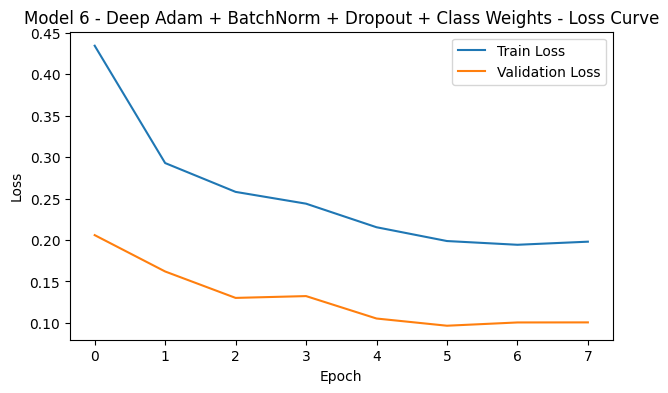

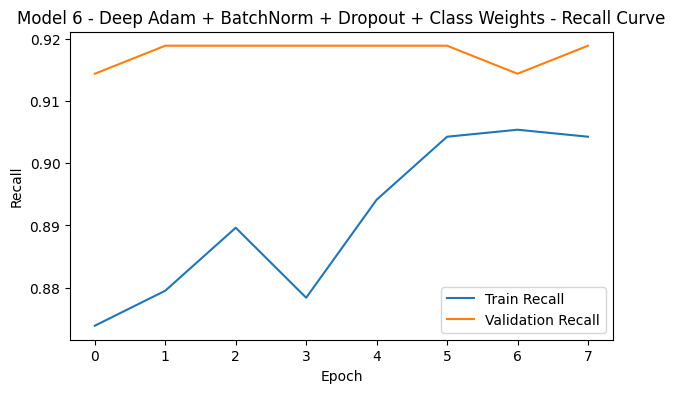

Model: Model 6 - Train
Decision Threshold: 0.5

Confusion Matrix:
[[14528   584]
 [  108   780]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9926    0.9614    0.9767     15112
           1     0.5718    0.8784    0.6927       888

    accuracy                         0.9567     16000
   macro avg     0.7822    0.9199    0.8347     16000
weighted avg     0.9693    0.9567    0.9610     16000


Key Metrics:
Threshold: 0.5000
Accuracy: 0.9567
Precision_1: 0.5718
Recall_1: 0.8784
F1_1: 0.6927
ROC_AUC: 0.9588
PR_AUC: 0.8734
Model: Model 6 - Validation
Decision Threshold: 0.5

Confusion Matrix:
[[3637  141]
 [  19  203]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9948    0.9627    0.9785      3778
           1     0.5901    0.9144    0.7173       222

    accuracy                         0.9600      4000
   macro avg     0.7925    0.9385    0.8479      4000
weighted avg     0.9723    0

In [80]:
model_6 = build_nn_model(
    input_dim=X_train_scaled.shape[1],
    hidden_layers=[256, 128, 64, 32],
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.25,
    batch_norm=True
)

history_6 = model_6.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=90,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

plot_training_history(history_6, "Model 6 - Deep Adam + BatchNorm + Dropout + Class Weights")

train_metrics_6 = print_detailed_evaluation(model_6, X_train_scaled, y_train, "Model 6 - Train")
val_metrics_6 = print_detailed_evaluation(model_6, X_val_scaled, y_val, "Model 6 - Validation")

training_results.append(train_metrics_6)
validation_results.append(val_metrics_6)
model_observation(val_metrics_6)

### Observations for Model 6

- This is the most complex model, using a deeper architecture, Adam optimizer, batch normalization, dropout, and class weights.
- Batch normalization can stabilize and speed up training.
- Dropout helps control overfitting, while class weights focus the model on the rare failure class.
- The model should be selected only if it improves validation recall and generalization without excessive instability or overfitting.

# Model Performance Comparison and Final Model Selection

In [81]:
# Creating consolidated training and validation performance tables
train_results_df = pd.DataFrame(training_results)
val_results_df = pd.DataFrame(validation_results)

print("Training Performance:")
display(train_results_df.sort_values(by="Recall_1", ascending=False))

print("Validation Performance:")
display(val_results_df.sort_values(by=["Recall_1", "F1_1", "PR_AUC"], ascending=False))

Training Performance:


,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
3,Model 3 - Train,0.5000,0.9941,0.9938,0.8998,0.9444,0.9867,0.9523
5,Model 5 - Train,0.5000,0.9177,0.3940,0.8953,0.5471,0.9457,0.8583
6,Model 6 - Train,0.5000,0.9567,0.5718,0.8784,0.6927,0.9588,0.8734
0,Model 0 - Train,0.5000,0.9906,0.9842,0.8435,0.9084,0.9595,0.9157
4,Model 4 - Train,0.5000,0.9796,0.9131,0.6982,0.7913,0.9416,0.8333
2,Model 2 - Train,0.5000,0.9445,0.0000,0.0000,0.0000,0.6843,0.0946
1,Model 1 - Train,0.5000,0.9445,0.0000,0.0000,0.0000,0.7874,0.2722


Validation Performance:


,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
6,Model 6 - Validation,0.5000,0.9600,0.5901,0.9144,0.7173,0.9486,0.8905
5,Model 5 - Validation,0.5000,0.9197,0.4016,0.9099,0.5572,0.9393,0.8784
3,Model 3 - Validation,0.5000,0.9938,0.9852,0.9009,0.9412,0.9606,0.9257
0,Model 0 - Validation,0.5000,0.9910,0.9745,0.8604,0.9139,0.9450,0.9184
4,Model 4 - Validation,0.5000,0.9805,0.9186,0.7117,0.8020,0.9324,0.8486
1,Model 1 - Validation,0.5000,0.9445,0.0000,0.0000,0.0000,0.7683,0.2662
2,Model 2 - Validation,0.5000,0.9445,0.0000,0.0000,0.0000,0.6355,0.0820


<Figure size 1400x600 with 0 Axes>

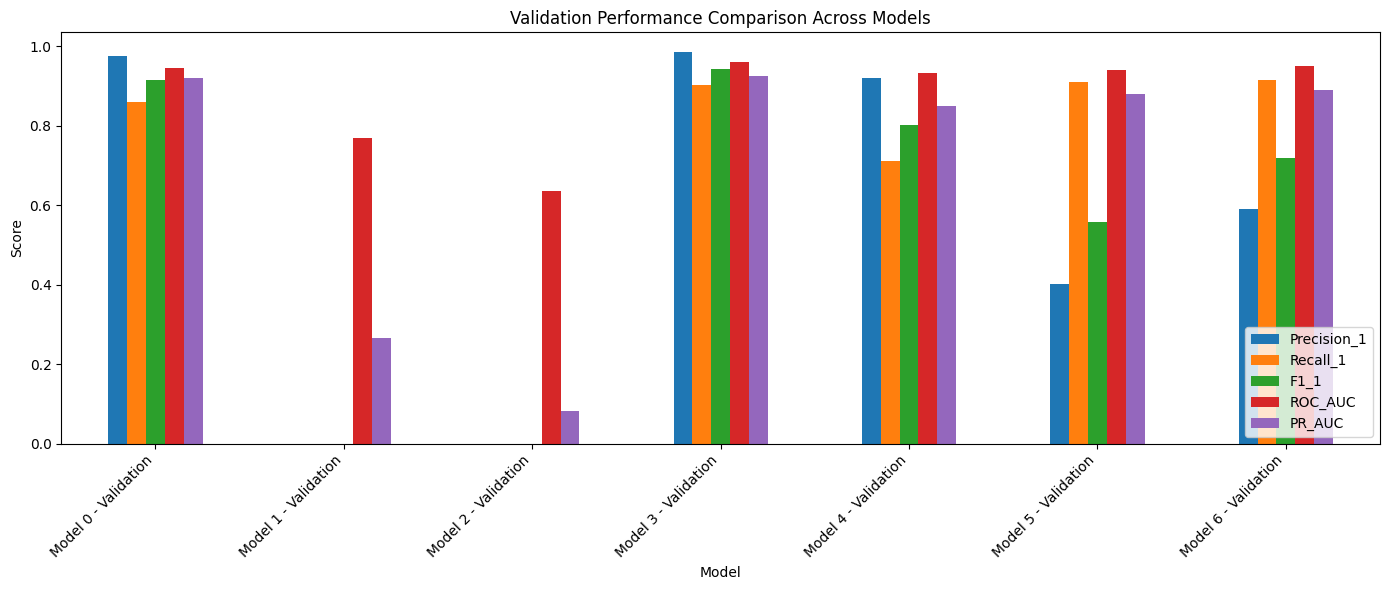

In [82]:
# Visualizing validation performance across models
metrics_to_plot = ["Precision_1", "Recall_1", "F1_1", "ROC_AUC", "PR_AUC"]

val_plot_df = val_results_df.set_index("Model")[metrics_to_plot]

plt.figure(figsize=(14, 6))
val_plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Validation Performance Comparison Across Models")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Observations from Model Comparison

- The models should be compared primarily on validation recall for class `1`, because missing an actual failure creates the highest business cost.
- Precision should also be reviewed because very low precision would create too many unnecessary inspections.
- F1-score gives a balanced view of precision and recall.
- PR-AUC is especially useful in this project because the failure class is rare.
- A model with slightly lower accuracy but much higher failure recall is preferable to a model with high accuracy but poor failure detection.

In [83]:
# Selecting the best model based on validation recall, with F1-score and PR-AUC as tie-breakers
best_model_row = val_results_df.sort_values(
    by=["Recall_1", "F1_1", "PR_AUC"],
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"].replace(" - Validation", "")
best_model_name, best_model_row

('Model 6',
 Model          Model 6 - Validation
 Threshold                    0.5000
 Accuracy                     0.9600
 Precision_1                  0.5901
 Recall_1                     0.9144
 F1_1                         0.7173
 ROC_AUC                      0.9486
 PR_AUC                       0.8905
 Name: 6, dtype: object)

In [84]:
# Mapping model names to trained model objects
trained_models = {
    "Model 0 - Train": model_0,
    "Model 1 - Train": model_1,
    "Model 2 - Train": model_2,
    "Model 3 - Train": model_3,
    "Model 4 - Train": model_4,
    "Model 5 - Train": model_5,
    "Model 6 - Train": model_6,
    "Model 0": model_0,
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5,
    "Model 6": model_6,
}

# Extracting the model number from the selected validation model name
selected_model_key = best_model_name
best_model = trained_models[selected_model_key]

print("Selected best model:", selected_model_key)

Selected best model: Model 6


## Threshold Tuning for Final Model

The default probability threshold is 0.50. However, in imbalanced predictive maintenance problems, a lower threshold may help identify more actual failures. Since missing failures is costly, threshold tuning is performed on the validation data using F2-score, which gives more weight to recall than precision.

In [85]:
# Function to calculate F-beta score manually for different thresholds
# F2-score gives more weight to recall than precision.
def fbeta_score_custom(precision, recall, beta=2):
    if precision == 0 and recall == 0:
        return 0
    beta_sq = beta ** 2
    return (1 + beta_sq) * precision * recall / ((beta_sq * precision) + recall)

# Predicting probabilities on validation data using the best model
val_probs = best_model.predict(X_val_scaled, verbose=0).ravel()

threshold_records = []

# Testing multiple thresholds to find the best recall-oriented threshold
for threshold in np.arange(0.10, 0.91, 0.05):
    val_preds = (val_probs >= threshold).astype(int)
    precision = precision_score(y_val, val_preds, zero_division=0)
    recall = recall_score(y_val, val_preds, zero_division=0)
    f1 = f1_score(y_val, val_preds, zero_division=0)
    f2 = fbeta_score_custom(precision, recall, beta=2)

    threshold_records.append({
        "Threshold": threshold,
        "Precision_1": precision,
        "Recall_1": recall,
        "F1_1": f1,
        "F2_1": f2
    })

threshold_df = pd.DataFrame(threshold_records)
threshold_df.sort_values(by=["F2_1", "Recall_1"], ascending=False).head(10)

,Threshold,Precision_1,Recall_1,F1_1,F2_1
13,0.7500,0.8008,0.8694,0.8337,0.8547
12,0.7000,0.7538,0.8829,0.8133,0.8537
10,0.6000,0.6667,0.9099,0.7695,0.8480
14,0.8000,0.8393,0.8468,0.8430,0.8453
11,0.6500,0.6947,0.8919,0.7811,0.8440
15,0.8500,0.8804,0.8288,0.8538,0.8387
9,0.5500,0.6246,0.9144,0.7422,0.8368
8,0.5000,0.5901,0.9144,0.7173,0.8239
7,0.4500,0.5244,0.9189,0.6678,0.7987
16,0.9000,0.9235,0.7613,0.8346,0.7890


In [86]:
# Selecting the threshold that maximizes F2-score
best_threshold = threshold_df.sort_values(by=["F2_1", "Recall_1"], ascending=False).iloc[0]["Threshold"]
best_threshold

np.float64(0.7500000000000002)

In [87]:
# Evaluating the selected model on validation data using the tuned threshold
final_val_metrics = print_detailed_evaluation(
    best_model,
    X_val_scaled,
    y_val,
    f"{selected_model_key} - Validation with Tuned Threshold",
    threshold=best_threshold
)
model_observation(final_val_metrics)

Model: Model 6 - Validation with Tuned Threshold
Decision Threshold: 0.7500000000000002

Confusion Matrix:
[[3730   48]
 [  29  193]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9923    0.9873    0.9898      3778
           1     0.8008    0.8694    0.8337       222

    accuracy                         0.9808      4000
   macro avg     0.8966    0.9283    0.9117      4000
weighted avg     0.9817    0.9808    0.9811      4000


Key Metrics:
Threshold: 0.7500
Accuracy: 0.9808
Precision_1: 0.8008
Recall_1: 0.8694
F1_1: 0.8337
ROC_AUC: 0.9486
PR_AUC: 0.8905
Automated Observation:
- The model achieved recall of 0.8694 for the failure class.
- Precision for the failure class is 0.8008, indicating the reliability of failure alerts.
- F1-score is 0.8337, showing the balance between recall and precision.
- PR-AUC is 0.8905, which is important for imbalanced classification problems.
- From a predictive maintenance perspective, this model is 

### Observations on Threshold Tuning

- Threshold tuning is useful because the default threshold of 0.50 may not be optimal for detecting rare failures.
- Lowering the threshold typically increases recall, which reduces missed failures.
- The trade-off is that precision may decrease, leading to more inspections.
- Since inspection cost is lower than replacement cost, this trade-off can be acceptable if recall improves meaningfully.
- The final threshold should be selected based on validation data only, not the final test data.

# Final Model Evaluation on Test Data

The test dataset should be used only once after selecting the final model and threshold using the training and validation data.

In [88]:
# Evaluating the final selected model on the test set
final_test_metrics = print_detailed_evaluation(
    best_model,
    X_test_scaled,
    y_test_final,
    f"{selected_model_key} - Final Test Performance",
    threshold=best_threshold
)
model_observation(final_test_metrics)

Model: Model 6 - Final Test Performance
Decision Threshold: 0.7500000000000002

Confusion Matrix:
[[4656   62]
 [  59  223]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9875    0.9869    0.9872      4718
           1     0.7825    0.7908    0.7866       282

    accuracy                         0.9758      5000
   macro avg     0.8850    0.8888    0.8869      5000
weighted avg     0.9759    0.9758    0.9759      5000


Key Metrics:
Threshold: 0.7500
Accuracy: 0.9758
Precision_1: 0.7825
Recall_1: 0.7908
F1_1: 0.7866
ROC_AUC: 0.9285
PR_AUC: 0.8384
Automated Observation:
- The model achieved recall of 0.7908 for the failure class.
- Precision for the failure class is 0.7825, indicating the reliability of failure alerts.
- F1-score is 0.7866, showing the balance between recall and precision.
- PR-AUC is 0.8384, which is important for imbalanced classification problems.
- The model captures a reasonable proportion of failures, but furthe

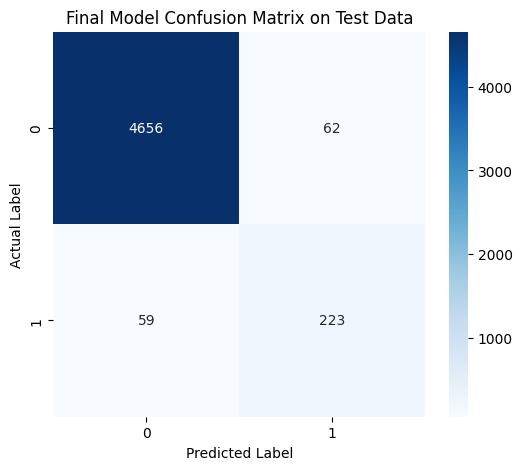

In [89]:
# Confusion matrix visualization for final test performance
y_test_prob = best_model.predict(X_test_scaled, verbose=0).ravel()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test_final, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model Confusion Matrix on Test Data")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [90]:
# Creating a final comparison table with selected validation and test performance
final_summary = pd.DataFrame([final_val_metrics, final_test_metrics])
final_summary

,Model,Threshold,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC,PR_AUC
0,Model 6 - Validation with Tuned Threshold,0.7500,0.9808,0.8008,0.8694,0.8337,0.9486,0.8905
1,Model 6 - Final Test Performance,0.7500,0.9758,0.7825,0.7908,0.7866,0.9285,0.8384


### Final Model Selection Rationale

The final model is selected based on validation performance, with priority given to **Recall for the failure class (`Target = 1`)**.

The selected model is appropriate for ReneWind because:

- It focuses on identifying actual generator failures.
- It helps reduce false negatives, which are the costliest errors in the business context.
- It balances recall with precision and F1-score to avoid generating excessive unnecessary inspections.
- Threshold tuning further aligns the model output with the predictive maintenance objective.
- The model was evaluated on the test set only after final selection, ensuring an unbiased estimate of performance.

# Actionable Insights and Recommendations

## Key Takeaways

- The dataset is highly imbalanced, with generator failures representing only a small percentage of total observations.
- Accuracy is not a reliable metric for this business problem because a model can achieve high accuracy by mostly predicting the majority no-failure class.
- Recall for the failure class is the most important metric because missed failures lead to replacement costs.
- Neural Network performance improves through experimentation with deeper architectures, optimizer changes, dropout, class weights, and threshold tuning.
- Class weights and threshold tuning are especially relevant because they directly address the minority failure class.

## Business Recommendations

1. **Use the final model as an early-warning system**  
   Turbines predicted as high-risk should be flagged for maintenance review before generator failure occurs.

2. **Prioritise high-risk turbines for inspection and repair**  
   Since inspection cost is lower than repair and replacement cost, the business should accept some false positives to avoid missing real failures.

3. **Monitor false negatives closely**  
   Any missed generator failures should be reviewed to identify new failure patterns and improve the model.

4. **Retrain the model periodically**  
   Sensor behaviour and turbine operating conditions may change over time, so the model should be retrained using recent data.

5. **Use model predictions with engineering judgement**  
   The model should support maintenance teams but should not fully replace expert inspection and operational decision-making.

6. **Create a risk-based maintenance workflow**  
   Predicted probabilities can be grouped into risk bands:
   - High risk: immediate inspection/repair planning
   - Medium risk: monitor closely and inspect during the next maintenance window
   - Low risk: continue normal monitoring

## Final Conclusion

The selected Neural Network model can help ReneWind move from reactive maintenance to predictive maintenance. By prioritising recall for the failure class, the model supports early detection of generator failures and can help reduce costly replacements, downtime, and operational disruption.